# ***Libraries***

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ***Loading the dataset from google drive***

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd
churn = pd.read_csv('/content/gdrive/MyDrive/Churn Prediction/churn.csv')
print(churn.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# ***Data Cleaning***

In [ ]:
churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
churn.drop("customerID", axis=1, inplace=True, errors='ignore')
print(churn.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [ ]:
print(churn.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print(churn.select_dtypes(include="object").columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
churn["TotalCharges"] = pd.to_numeric(churn["TotalCharges"], errors="coerce")

churn["TotalCharges"] = churn["TotalCharges"].fillna(
    churn["TotalCharges"].median()
)

In [ ]:
churn["Churn"] = churn["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
churn = pd.get_dummies(churn, drop_first=True)

In [ ]:
print(churn.head())
print(churn.info())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

# ***Correlation***

In [ ]:
print(churn.corr()["Churn"].sort_values(ascending=False))

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


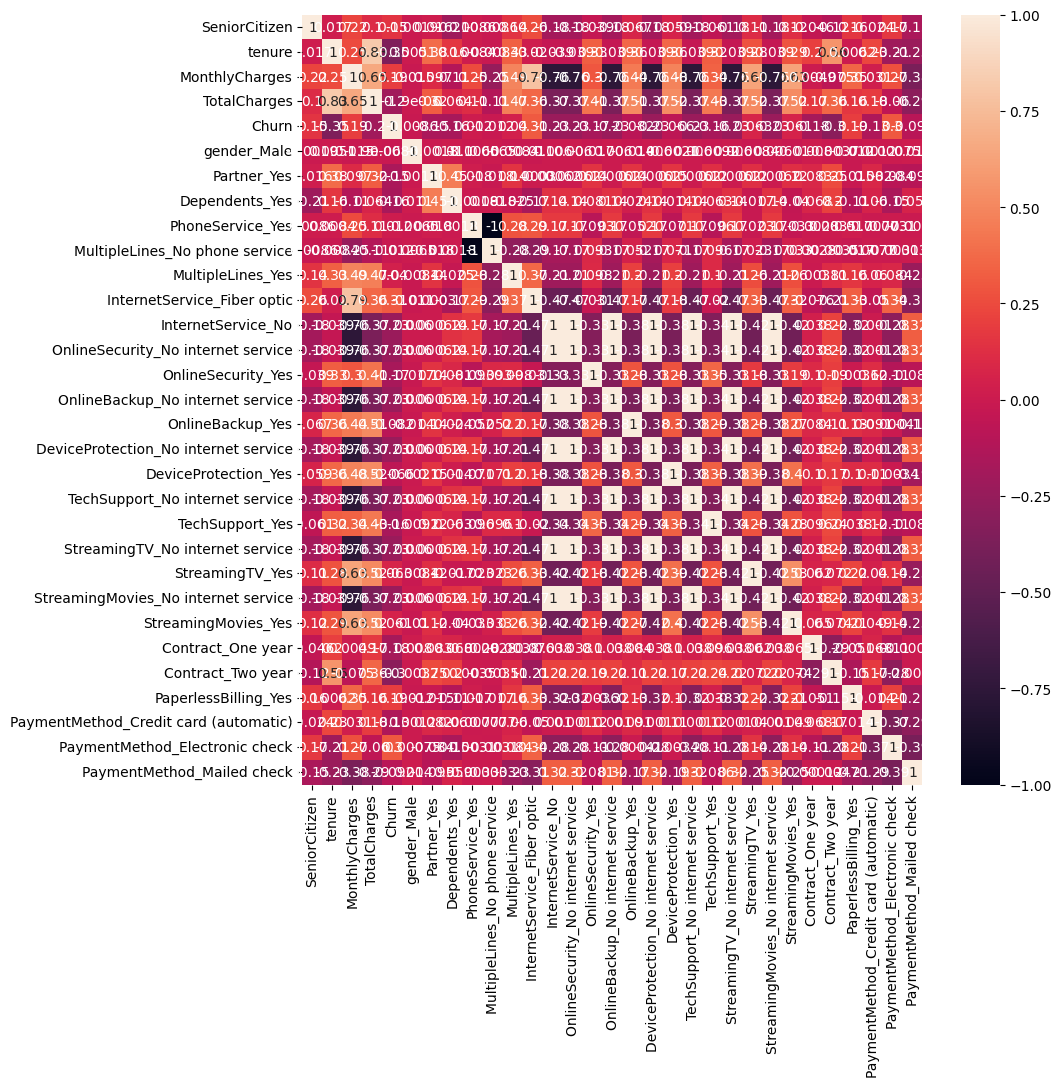

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
sns.heatmap(churn.corr(), annot=True)
plt.show()

In [ ]:
X = churn.drop("Churn", axis=1)
y = churn["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.174188
1                           tenure    0.166575
2                   MonthlyCharges    0.155530
25               Contract_Two year    0.060160
10     InternetService_Fiber optic    0.038785
28  PaymentMethod_Electronic check    0.034724
13              OnlineSecurity_Yes    0.030879
24               Contract_One year    0.029938
4                      gender_Male    0.025630
26            PaperlessBilling_Yes    0.023959


In [ ]:
# Get probability predictions
y_prob = model.predict_proba(X_test)

# Probability of churn (class 1)
churn_prob = y_prob[:, 1]

print(churn_prob[:10])

[0.   0.76 0.07 0.34 0.   0.48 0.45 0.1  0.01 0.44]


In [ ]:
def risk_level(prob):
    if prob > 0.7:
        return "HIGH"
    elif prob > 0.4:
        return "MEDIUM"
    else:
        return "LOW"

risk_levels = [risk_level(p) for p in churn_prob]

print(risk_levels[:10])

['LOW', 'HIGH', 'LOW', 'LOW', 'LOW', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW', 'MEDIUM']


In [ ]:
importance.head(10)

,Feature,Importance
3,TotalCharges,0.174188
1,tenure,0.166575
2,MonthlyCharges,0.155530
25,Contract_Two year,0.060160
10,InternetService_Fiber optic,0.038785
28,PaymentMethod_Electronic check,0.034724
13,OnlineSecurity_Yes,0.030879
24,Contract_One year,0.029938
4,gender_Male,0.025630
26,PaperlessBilling_Yes,0.023959


In [ ]:
top_features = importance.head(3)["Feature"].values
print("Top factors influencing churn:", top_features)

Top factors influencing churn: ['TotalCharges' 'tenure' 'MonthlyCharges']


In [ ]:
def recommendation(risk):
    if risk == "HIGH":
        return "Offer discount or retention plan"
    elif risk == "MEDIUM":
        return "Monitor and engage customer"
    else:
        return "No immediate action needed"

recommendations = [recommendation(r) for r in risk_levels]

print(recommendations[:5])

['No immediate action needed', 'Offer discount or retention plan', 'No immediate action needed', 'No immediate action needed', 'No immediate action needed']


In [ ]:
import joblib

joblib.dump(model, "churn_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
from google.colab import files

files.download("churn_model.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir())

['.config', 'churn_model.pkl', 'feature_columns.pkl', 'gdrive', 'sample_data']


In [ ]:
import shutil

shutil.make_archive("churn_project_files", 'zip', '.')

RuntimeError: File size too large, try using force_zip64

In [ ]:
from google.colab import files

files.download("churn_project_files.zip")